### Import and Setup

In [1]:
import os
import sys

sys.path.append(os.path.abspath("../scr"))

from baseline_analysis import split_training_data
from utils import get_available_gpu, EarlyStopping

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import pandas as pd
from tqdm.notebook import tqdm
import seaborn as sns
import torch
from scipy.stats import spearmanr
from torch.optim.lr_scheduler import ReduceLROnPlateau


device = get_available_gpu()

Selected GPU: 2 | Memory Used: 14 MB
Selected GPU: 3 | Memory Used: 14 MB


### Define Simple CNN Model

In [2]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(32 * 56 * 56, 128)
        self.fc2 = nn.Linear(128, 1)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = torch.flatten(x, 1)
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)  # No activation for regression
        return x


### Load data

In [3]:
image_directory = "/mnt/research-projects/j/jlgage/RawUAVData01/data/images"
csv_file = "/mnt/research-projects/j/jlgage/RawUAVData01/data/all_scored_images.csv"

train_loader, val_loader, test_loader = split_training_data(image_directory, csv_file, batch_size=32)

2025-03-31 14:34:02,394 - baseline_analysis - INFO - Total valid images after filtering: 9831
2025-03-31 14:34:02,399 - baseline_analysis - INFO - Data split: Train=6881, Validation=1475, Test=1475


### Train model

/home/chhammet/miniforge3/envs/uav_regression_env/lib/python3.9/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


  0%|          | 0/216 [00:00<?, ?it/s]

Epoch 1, Train Loss: 7.0181, Val Loss: 2.3908


  0%|          | 0/216 [00:00<?, ?it/s]

Epoch 2, Train Loss: 2.0361, Val Loss: 1.5860


...

  0%|          | 0/216 [00:00<?, ?it/s]

Epoch 8, Train Loss: 1.5882, Val Loss: 1.9872


  0%|          | 0/216 [00:00<?, ?it/s]

Epoch 9, Train Loss: 1.5189, Val Loss: 2.3837
Early stopping triggered at epoch 9


ValueError: x and y must have same first dimension, but have shapes (10,) and (9,)

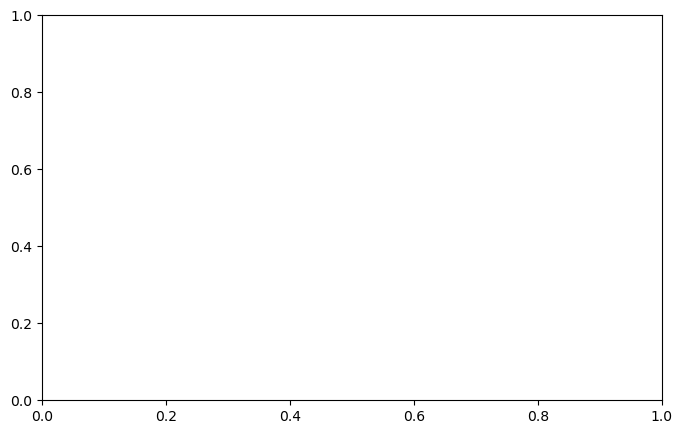

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = SimpleCNN().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2, verbose=True)
early_stopping = EarlyStopping(patience=3, min_delta=0.001)


num_epochs = 10

train_losses = []
val_losses = []

for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    loop = tqdm(train_loader, leave=False)
    for images, scores in loop:
        images, scores = images.to(device), scores.to(device).unsqueeze(1)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, scores)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * images.size(0)
        loop.set_description(f"Epoch [{epoch+1}/{num_epochs}]")
        loop.set_postfix(loss=loss.item())

    train_loss /= len(train_loader.dataset)
    train_losses.append(train_loss)

    # Validation loss
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for images, scores in val_loader:
            images, scores = images.to(device), scores.to(device).unsqueeze(1)
            outputs = model(images)
            loss = criterion(outputs, scores)
            val_loss += loss.item() * images.size(0)

    val_loss /= len(val_loader.dataset)
    val_losses.append(val_loss)
    scheduler.step(val_loss)

    print(f"Epoch {epoch+1}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

    early_stopping(val_loss)

    if early_stopping.early_stop:
        print(f"Early stopping triggered at epoch {epoch+1}")
        break

# Plot losses
epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_losses, label='Training Loss')
plt.plot(epochs, val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Training & Validation Loss')
plt.legend()
plt.grid(True)
plt.show()



### Evaluate Model

In [5]:
import numpy as np

model.eval()
predictions = []
actuals = []

with torch.no_grad():
    for images, scores in val_loader:
        images, scores = images.to(device), scores.to(device).unsqueeze(1)
        outputs = model(images)
        predictions.extend(outputs.cpu().numpy())
        actuals.extend(scores.cpu().numpy())

predictions = np.array(predictions).flatten()
actuals = np.array(actuals).flatten()

rmse = np.sqrt(np.mean((predictions - actuals) ** 2))
print(f"Validation RMSE: {rmse:.4f}")


Validation RMSE: 1.5439


In [6]:
from sklearn.metrics import mean_absolute_error, r2_score

mae = mean_absolute_error(actuals, predictions)
r2 = r2_score(actuals, predictions)
spearman_corr, p_value = spearmanr(actuals, predictions)

print(f"Spearman Correlation: {spearman_corr:.4f} (p-value: {p_value:.4f})")
print(f"Validation MAE: {mae:.4f}")
print(f"Validation R² Score: {r2:.4f}")

Spearman Correlation: 0.7409 (p-value: 0.0000)
Validation MAE: 1.2525
Validation R² Score: 0.0609


### Visualize

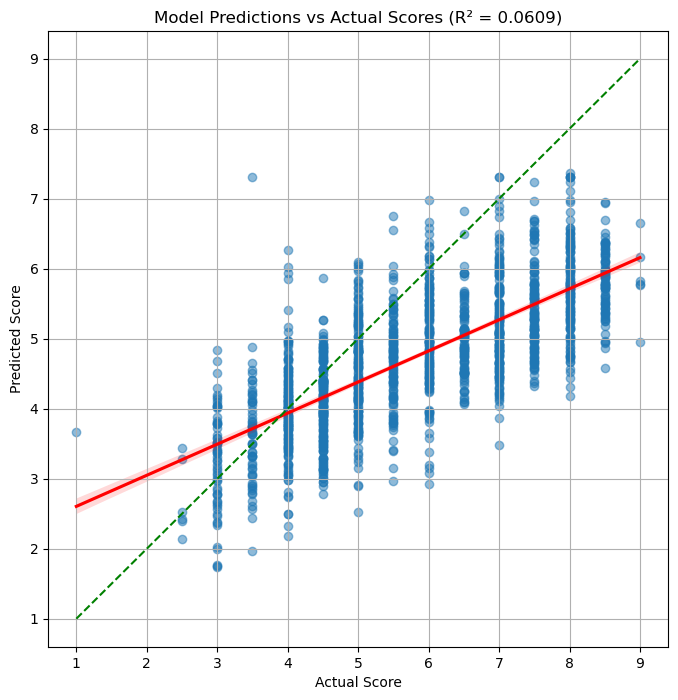

In [7]:
# Create data for visualization
df_results = pd.DataFrame({'Actual': actuals, 'Predicted': predictions})
df_results['Error'] = np.abs(df_results['Actual'] - df_results['Predicted'])

# Improved scatter plot
plt.figure(figsize=(8, 8))
sns.regplot(x='Actual', y='Predicted', data=df_results, scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.plot([min(actuals), max(actuals)], [min(actuals), max(actuals)], color='green', linestyle='--')
plt.xlabel('Actual Score')
plt.ylabel('Predicted Score')
plt.title('Model Predictions vs Actual Scores (R² = {:.4f})'.format(r2))
plt.grid(True)
plt.show()

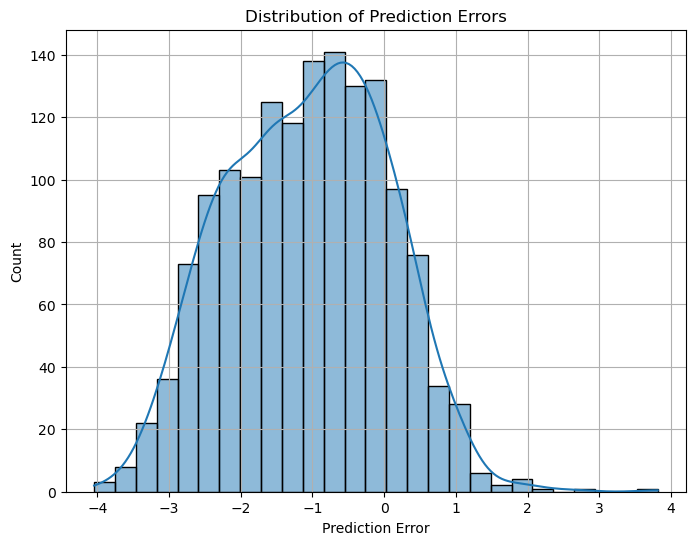

In [8]:
plt.figure(figsize=(8, 6))
residuals = predictions - actuals
sns.histplot(residuals, kde=True)
plt.xlabel('Prediction Error')
plt.ylabel('Count')
plt.title('Distribution of Prediction Errors')
plt.grid(True)
plt.show()